# CLN from a 3D circular wire: A–φ, T–Ω, and A–T

Three NGSolve formulations are reproduced from Tanimoto's student notebooks. The unknowns differ, but comparisons use reconstructed electric fields, magnetic flux densities, and circuit constants extracted from energy in the same order.

**Scope: cylindrical conductor interior, linear material, expansion point $s_0=0$, and $R_0,L_1,R_2$.** Exterior air, return conductors, nonzero shifts, higher stages, and multiply connected domains are excluded. Independent Claude review is pending. The cells inspect stored execution results; the final instructions reproduce the FEM solves.

## Align normalization first

Radius $a=0.01$ m, length $h=0.01$ m, conductivity $\sigma=10^6$ S/m, permeability $\mu=4\pi 10^{-7}$ H/m. The initial axial electric field is $1$ V/m, corresponding to terminal voltage $h$ V. In these coordinates,

$$R_0=\frac{1}{\pi a^2\sigma h},\qquad L_1=\frac{\mu}{8\pi h},\qquad R_2=3R_0.$$

For a circuit normalized to terminal voltage 1 V, multiply each coefficient by $h^2$. Do not directly interpret the stored numbers as terminal Ω/H. Magnetic energy includes only the conductor interior.

## Boundary conditions and gauges

A–φ applies voltage through end-face φ values and constrains tangential A on the surface. T–Ω and A–T apply an initial-electric-field boundary source on the side. Ω has natural boundary conditions. These formulation-specific designs are retained.

The curl–curl matrix retains a gradient nullspace. Making the right-hand side orthogonal to that kernel and making the matrix nonsingular are different operations. With discrete gradient matrix $G$, ICCG solves

$$A_g=A+\alpha GG^T,\qquad \alpha>0.$$

The code checks $AG\simeq0$ on free degrees of freedom and evaluates residuals against the **original matrix A**. Projection magnitude and residual against the unprojected source are recorded separately. Projection changes the load and cannot be justified by gauge invariance alone. Coupled scalar/vector forms use matched bonus quadrature on curved elements. Default quadrature previously introduced a nonphysical compatibility defect that increased with stage count. The run stops if the removed fraction exceeds $10^{-8}$. This correction does not validate higher-stage circuit accuracy.

Scalar spaces in A–φ/T–Ω use one order higher than vector spaces to represent gradient-based field reconstruction. The ICCG shift is unchanged and separate from gauge weight α.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
root=Path.cwd()
if not (root/'validation').is_dir():
    root=root.parent
record=json.loads((root/'docs/data/three_dimensional.json').read_text(encoding='utf-8'))
cases=record['cases']
print(record['scope'])
print('formulation   mesh h [m]    R0 error[%]    L1 error[%]    R2 error[%]')
for c in cases:
    print(f"{c['formulation']:11}   {c['maxh']:.4f}        " + '   '.join(f'{100*x:10.5f}' for x in c['relative_errors']))
for c in cases:
    for info in c['result']['solves']:
        assert info['explicit_residual'] <= 1e-7
        assert info['original_rhs_residual'] <= 1.001e-4
print('Residual checks passed')


3D cylinder, internal energy, s0=0, order=1, R0/L1/R2
formulation   mesh h [m]    R0 error[%]    L1 error[%]    R2 error[%]
A-phi         0.0030           0.00064      2.00325      4.80037
A-phi         0.0010           0.00001      0.24717      0.66707
T-Omega       0.0030           0.02466      0.27211     18.24162
T-Omega       0.0010           0.00095      0.01183      2.10752
A-T           0.0030           0.02466      1.72675     12.97638
A-T           0.0010           0.00095      0.23528      1.43046
Residual checks passed


## Separate convergence of circuit constants from convergence of fields

Matching integrals alone does not establish matching fields. All three components of electric field and magnetic flux density are compared with analytic expressions at 25 points along the positive-x radial ray at mid-height.

The initial field is $E_{0,z}=1$, the first magnetic field is $B_{1,\theta}=\mu R_0\sigma r/2$, and the next electric field is $E_{2,z}=2(r/a)^2-1$. The plot shows axial electric field, but error checks include the full vector. Point-sample RMS error is not a volume norm.


A-phi finest field RMS: {'E0': 2.057732175755385e-08, 'B1': 0.04479795336699194, 'E2': 0.004268541520752894}
T-Omega finest field RMS: {'E0': 0.0003596148208813986, 'B1': 7.859586409308155e-05, 'E2': 0.07882108919945258}
A-T finest field RMS: {'E0': 0.00035961482027398027, 'B1': 0.044802778551905724, 'E2': 0.07886999227762918}


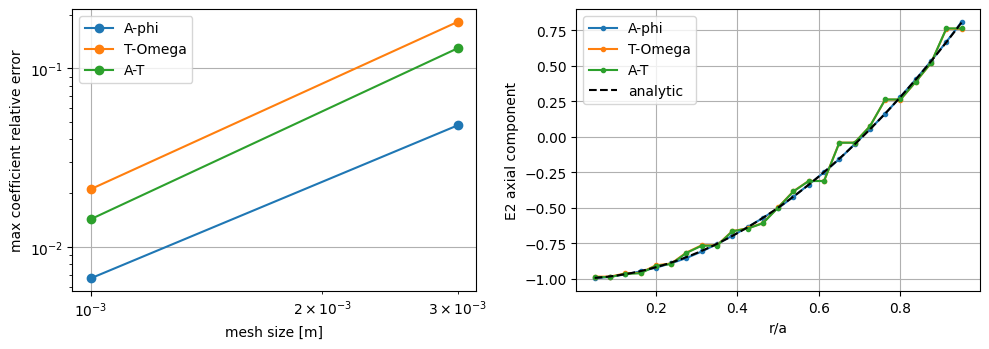

In [2]:
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for name in ['A-phi','T-Omega','A-T']:
    rows=[c for c in cases if c['formulation']==name]
    coarse,fine=rows
    assert all(a>2.5*b for a,b in zip(coarse['relative_errors'],fine['relative_errors']))
    axes[0].loglog([c['maxh'] for c in rows],[max(c['relative_errors']) for c in rows],'o-',label=name)
    p=fine['result']['field_profiles']
    axes[1].plot(p['rho'],np.asarray(p['E2'])[:,2],'.-',label=name)
    print(name,'finest field RMS:',fine['field_relative_rms'])
rho=np.linspace(.05,.95,150)
axes[1].plot(rho,2*rho**2-1,'k--',label='analytic')
axes[0].set(xlabel='mesh size [m]',ylabel='max coefficient relative error')
axes[1].set(xlabel='r/a',ylabel='E2 axial component')
for ax in axes:
    ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()


## Solver robustness under a gradient penalty

Penalty weights 0.1, 1, and 10 are compared on the same mesh and projected load. Their invariance is algebraically expected; this checks solver conditioning and precision, not an independent gauge choice or completeness of the kernel basis. This does not vary the ICCG acceleration shift. Circuit constants remain stable while iteration counts change substantially; a stronger gauge term is not necessarily better.

The check compares all three circuit constants and electric/magnetic fields at the same 25 points. It does not establish guarantees for arbitrary geometry, order, or stage count.


In [3]:
gauge=json.loads((root/'docs/data/three_dimensional_gauge.json').read_text(encoding='utf-8'))
for name,item in gauge.items():
    if name == "provenance": continue
    change=item['max_relative_gauge_change']
    assert change < 1e-7
    print(name, 'max relative circuit change:',f'{change:.3e}')
    assert max(item['max_relative_field_change'].values()) < 1e-7
    print('  physical field changes:',item['max_relative_field_change'])
    print('  weights / ICCG iterations:',[(r['weight'],[s['iterations'] for s in r['solves']]) for r in item['runs']])
# R and L in terminal coordinates for this cylinder.
fine=next(c for c in cases if c['formulation']=='A-phi' and c['maxh']==min(x['maxh'] for x in cases))
h=fine['result']['params']['h']
print('A-phi terminal [R0,L1,R2]:',np.asarray(fine['coefficients'])*h**2)


CLN_APhi max relative circuit change: 4.506e-13
  physical field changes: {'E0': 1.2275088630451245e-15, 'B1': 4.3085663973202994e-11, 'E2': 2.9130850679645376e-11}
  weights / ICCG iterations: [(0.1, [23, 20, 23]), (1.0, [23, 27, 23]), (10.0, [23, 51, 23])]
CLN_T_Omega max relative circuit change: 9.454e-12
  physical field changes: {'E0': 2.6885378088633302e-11, 'B1': 1.457124864296783e-11, 'E2': 4.1920956048650665e-11}
  weights / ICCG iterations: [(0.1, [24, 25, 23]), (1.0, [46, 25, 46]), (10.0, [1334, 25, 1446])]
CLN_AT max relative circuit change: 1.076e-11
  physical field changes: {'E0': 4.342862107849774e-11, 'B1': 3.960330089188127e-11, 'E2': 6.750410358786785e-11}
  weights / ICCG iterations: [(0.1, [24, 20, 23]), (1.0, [46, 27, 46]), (10.0, [1424, 51, 1691])]
A-phi terminal [R0,L1,R2]: [3.18309865e-05 4.98764144e-10 9.48559593e-05]


## Reproduction and self-review scope

Public code is in [validation/validate_3d.py](../validation/validate_3d.py) and the [three formulations](../validation/cln3d/). Install NGSolve, numpy, scipy, and the public Radia package in the same Python environment; run from the repository root.

```text
python validation/validate_3d.py --output docs/data/three_dimensional.json
python validation/cln3d/verify_gauge.py --output docs/data/three_dimensional_gauge.json
```

The first command recomputes three formulations on two meshes and checks positive energy, residuals against the original curl–curl matrix, refinement improvement, and analytic fields. The second checks gauge-weight sensitivity. The output paths above match the notebook evidence files. The gauge record includes runtime and source hashes.

Self-review checked fresh GridFunctions for each solve, preserved boundary lifting, explicit load-projection magnitudes, and separation of field-coordinate normalization from terminal values. The student-notebook history was not modified.

The formulations do not agree exactly on these finite meshes. This is a reproduction showing agreement as errors decrease. See [Type1](type1_same_circuit.ipynb) and [Type2](type2_same_circuit.ipynb) for nonzero-shift proofs; this 3D calculation is not a 3D extension of those proofs.


Acceptance uses reported residual ≤ 10·tol and explicit residual ≤ 1000·tol; these are distinct from the requested solver tolerance. A false native convergence flag is reported and warned about when these residual gates accept it. CLI requests above one stage warn that coefficient accuracy is unverified.

Higher-stage compatibility is not established: with `--quick --stages 3`, T–Ω fails the strict load-compatibility gate at about 1.224e-8 (limit 1e-8). A–φ passes that gate at three stages, but its higher-stage circuit accuracy is not validated. The one-stage T–Ω removed fraction is about 1.44e-9 on this coarse mesh.